# Japan Trade Intelligence — 02: Comparative Analysis

**Input:** master_trade.csv (6 countries) + FRED USD/JPY exchange rate
**Goal:** Compare Japan's trade growth against 5 major economies and 
test whether yen weakness explains Japan's trade balance.

In [1]:
# Setup
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load from processed (Already cleaned, correct years, correct cols and dtypes)
master = pd.read_csv("../data/processed/master_trade.csv")

print(f"Master shape: {master.shape}")
print(f"Reporters: {master['reporter'].unique()}")
print(f"Years: {sorted(master['year'].unique())}")

Master shape: (26951, 5)
Reporters: <StringArray>
['Japan', 'China', 'Germany', 'USA', 'Rep. of Korea', 'United Kingdom']
Length: 6, dtype: str
Years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [2]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 15,
    'axes.titleweight': '500',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

### Comparative Dataset

In [3]:
# why filter partner == 'World'
# For country-level comparison we want each country's Total trade value per year - not bilateral breakdowns
# world row = each country's official self - repoterd total

comparative = master[master['partner'] == 'World'].copy()

print(f"Comparative shape: {comparative.shape}")
print(f"\nRows per country:")
print(comparative.groupby('reporter')['year'].count())

Comparative shape: (120, 5)

Rows per country:
reporter
China             20
Germany           20
Japan             20
Rep. of Korea     20
USA               20
United Kingdom    20
Name: year, dtype: int64


### Total Exports Per Country Per Year

In [4]:
# Each column = one country's export trend

exports = comparative[comparative['flow'] == 'Export'].copy()
imports = comparative[comparative['flow'] == 'Import'].copy()

# Convert to billions
exports['value_bn'] = exports['value_usd'] / 1e9
imports['value_bn'] = imports['value_usd'] / 1e9

# pivot_table handles duplicates entries gracefully 
# but pivot crashes if any year-reporter combination appear twich 
# so we will handle it with aggfunc='sum'

exports_pivot = exports.pivot_table(
    index='year',
    columns='reporter',
    values='value_bn',
    aggfunc='sum'
)

imports_pivot = imports.pivot_table(
    index='year',
    columns='reporter',
    values='value_bn',
    aggfunc='sum'
)

print("Exports pivot shape: ", exports_pivot.shape)
print("\nExports pivot (first 3 rows):")
print(exports_pivot.head(3).round(1))

Exports pivot shape:  (10, 6)

Exports pivot (first 3 rows):
reporter   China  Germany  Japan  Rep. of Korea     USA  United Kingdom
year                                                                   
2014      2342.3   1498.2  690.2          573.1  1619.7           511.1
2015      2273.5   1328.5  624.9          526.8  1501.8           466.3
2016      2097.6   1337.2  644.9          495.4  1450.9           411.5


### Export Trends All 6 Countries Plot

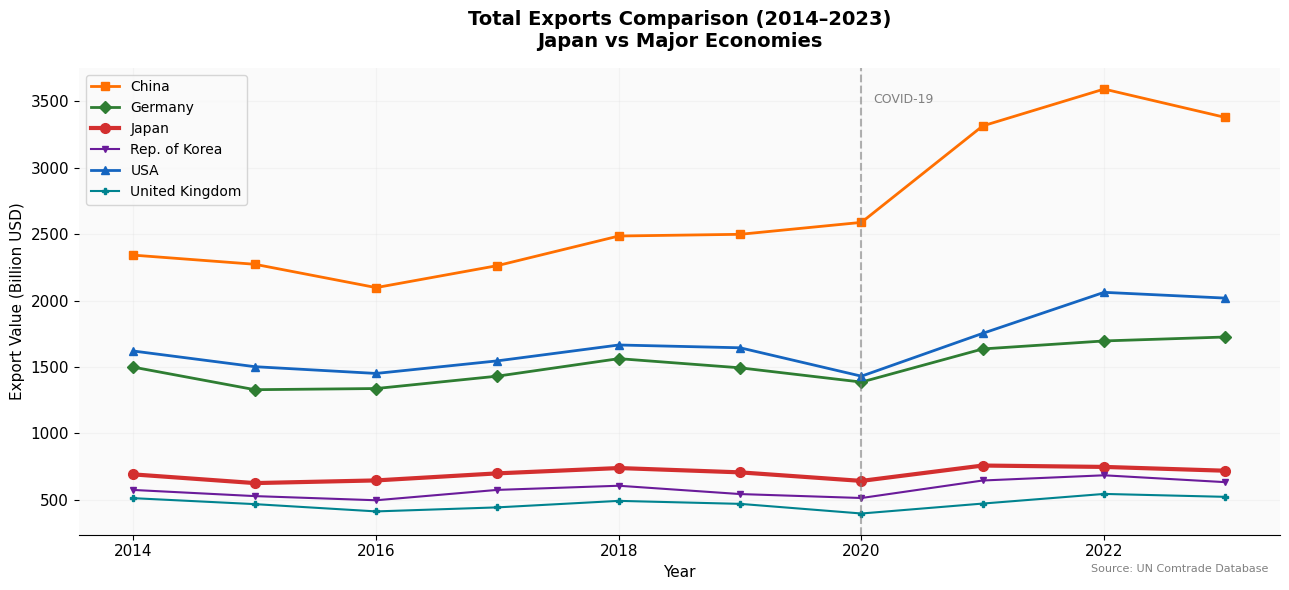

✓ Chart saved


In [5]:
# Japan in isolation tells us Japan's story
# Japan vs 5 other economies tells us Japan's POSITION
# Is Japan growing or just holding still while others surge?


fig, ax = plt.subplots(figsize=(13, 6))

# Color each country distinctly
country_styles = {
    'Japan':          {'color': '#D32F2F', 'lw': 3,   'marker': 'o', 'ms': 7},
    'China':          {'color': '#FF6F00', 'lw': 2,   'marker': 's', 'ms': 6},
    'USA':            {'color': '#1565C0', 'lw': 2,   'marker': '^', 'ms': 6},
    'Germany':        {'color': '#2E7D32', 'lw': 2,   'marker': 'D', 'ms': 6},
    'Rep. of Korea':  {'color': '#6A1B9A', 'lw': 1.5, 'marker': 'v', 'ms': 5},
    'United Kingdom': {'color': '#00838F', 'lw': 1.5, 'marker': 'P', 'ms': 5},
}

for country in exports_pivot.columns:
    if country in country_styles:
        style = country_styles[country]
        ax.plot(exports_pivot.index,
                exports_pivot[country],
                label=country,
                color=style['color'],
                linewidth=style['lw'],
                marker=style['marker'],
                markersize=style['ms'])

# WHY Japan gets thicker line (lw=3):
# This is Japan's story — make it visually prominent
# Other countries are context, Japan is the subject

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.6)
ax.text(2020.1, exports_pivot.max().max()*0.97,
        'COVID-19', fontsize=9, color='gray')

ax.set_title("Total Exports Comparison (2014–2023)\nJapan vs Major Economies",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Export Value (Billion USD)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.text(0.99, -0.08, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/comparative_exports.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

### Plot: Import Trends ALL 6 Countries

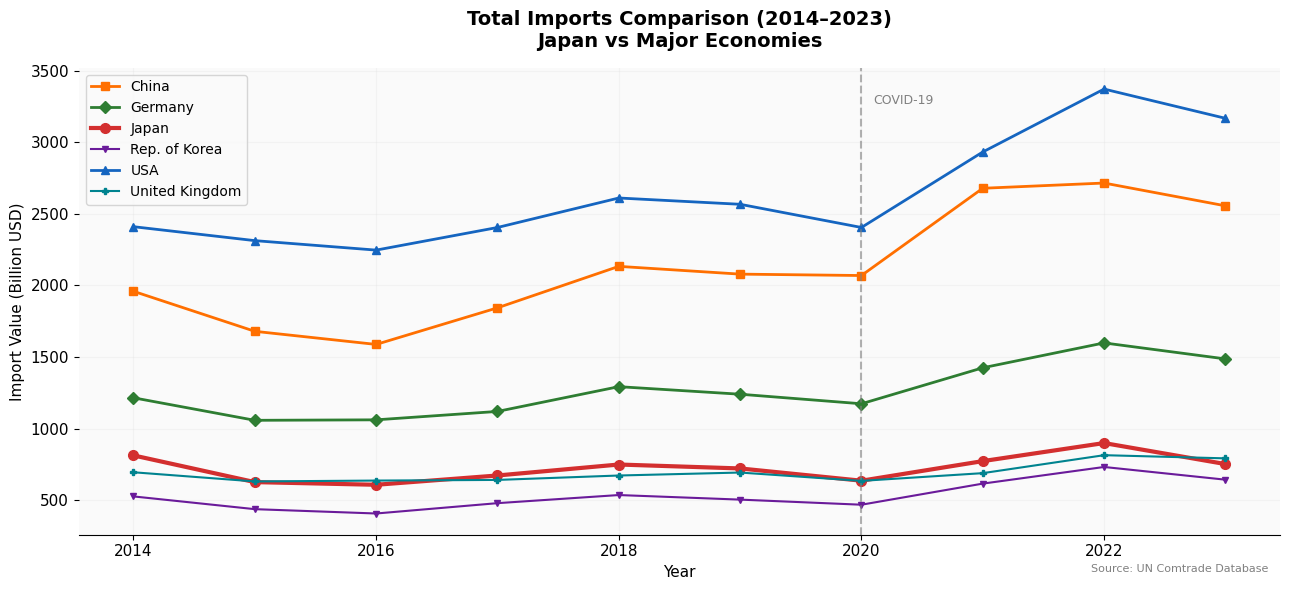

✓ Chart saved


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))

for country in imports_pivot.columns:
    if country in country_styles:
        style = country_styles[country]
        ax.plot(imports_pivot.index,
                imports_pivot[country],
                label=country,
                color=style['color'],
                linewidth=style['lw'],
                marker=style['marker'],
                markersize=style['ms'])

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.6)
ax.text(2020.1, imports_pivot.max().max()*0.97,
        'COVID-19', fontsize=9, color='gray')

ax.set_title("Total Imports Comparison (2014–2023)\nJapan vs Major Economies",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Import Value (Billion USD)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.text(0.99, -0.08, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/comparative_imports.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

### 2023 Snapshot: Who Exports Most?

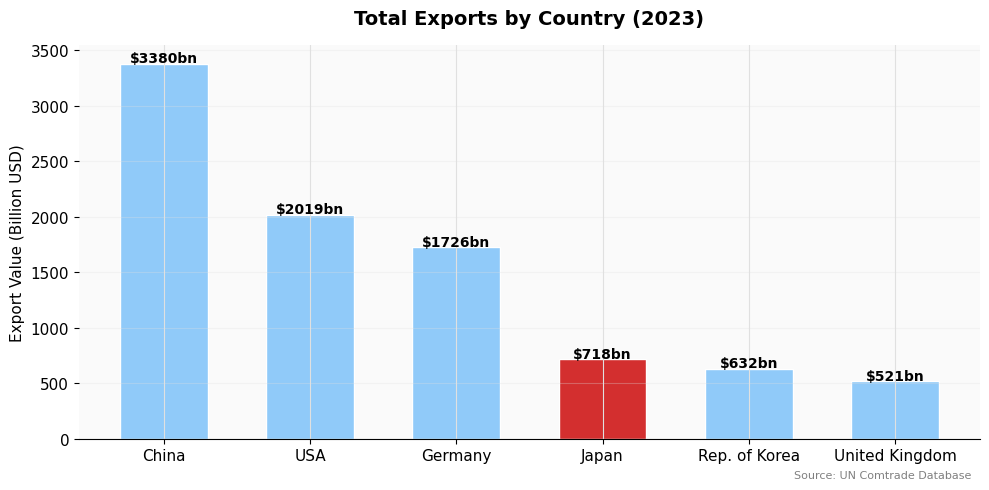


2023 Export Rankings:
  1. China: $3379.7bn
  2. USA: $2018.5bn
  3. Germany: $1725.5bn
  4. Japan: $717.9bn
  5. Rep. of Korea: $631.8bn
  6. United Kingdom: $521.2bn


In [7]:
# Line chart = trend over time (already shown above)
# Bar chart = comparison at one point in time
# 2023 snapshot gives the current ranking clearly

exports_2023 = exports_pivot.loc[2023].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#D32F2F' if c == 'Japan' else '#90CAF9'
          for c in exports_2023.index]

bars = ax.bar(exports_2023.index, exports_2023.values,
              color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, exports_2023.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'${val:.0f}bn',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title("Total Exports by Country (2023)",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Export Value (Billion USD)", fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/exports_2023_ranking.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n2023 Export Rankings:")
for rank, (country, val) in enumerate(exports_2023.items(), 1):
    print(f"  {rank}. {country}: ${val:.1f}bn")

### Growth Rate Analysis

In [8]:
# WHY growth rate matters more than absolute value:
# China's exports are larger in absolute terms
# But is China GROWING faster than Japan?
# Growth rate = the real competitive signal

# Calculate % change from 2014 baseline
# WHY 2014 as base: it's our earliest complete year
# Setting all countries to 100 in 2014 makes growth
# directly comparable regardless of starting size

baseline_year = 2014

exports_growth = exports_pivot.copy()
for country in exports_growth.columns:
    base = exports_growth.loc[baseline_year, country]
    exports_growth[country] = (exports_growth[country] / base * 100)

print("Export Growth Index (2014 = 100):")
print(exports_growth.round(1).to_string())

Export Growth Index (2014 = 100):
reporter  China  Germany  Japan  Rep. of Korea    USA  United Kingdom
year                                                                 
2014      100.0    100.0  100.0          100.0  100.0           100.0
2015       97.1     88.7   90.5           91.9   92.7            91.2
2016       89.6     89.3   93.4           86.4   89.6            80.5
2017       96.6     95.5  101.1          100.1   95.4            86.4
2018      106.2    104.3  107.0          105.5  102.8            96.0
2019      106.7     99.7  102.2           94.6  101.5            91.6
2020      110.5     92.5   92.9           89.4   88.3            77.4
2021      141.6    109.2  109.7          112.4  108.2            92.1
2022      153.4    113.2  108.2          119.3  127.3           106.3
2023      144.3    115.2  104.0          110.2  124.6           102.0


### Plot Growth Index

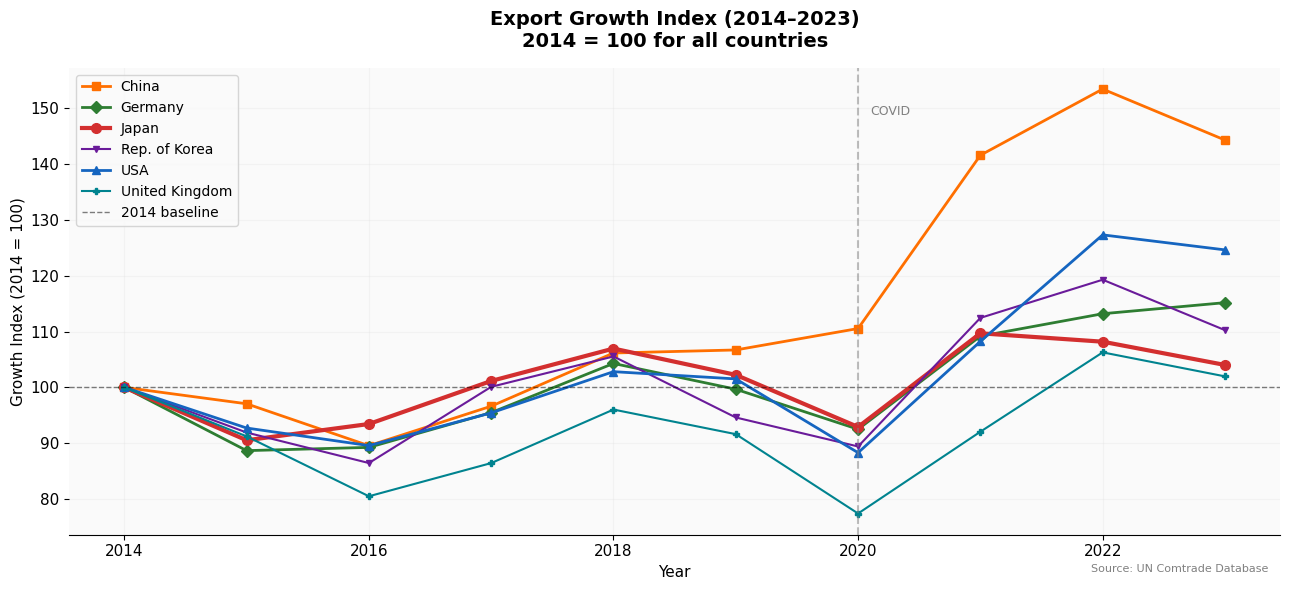

✓ Chart saved


In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

for country in exports_growth.columns:
    if country in country_styles:
        style = country_styles[country]
        ax.plot(exports_growth.index,
                exports_growth[country],
                label=country,
                color=style['color'],
                linewidth=style['lw'],
                marker=style['marker'],
                markersize=style['ms'])

# WHY baseline reference line:
# The 100 line = "same as 2014"
# Above 100 = growing. Below 100 = shrinking.
# Makes the chart instantly readable
ax.axhline(y=100, color='black', linewidth=1,
           linestyle='--', alpha=0.5, label='2014 baseline')

ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, exports_growth.max().max()*0.97,
        'COVID', fontsize=9, color='gray')

ax.set_title("Export Growth Index (2014–2023)\n2014 = 100 for all countries",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Growth Index (2014 = 100)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.text(0.99, -0.08, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/export_growth_index.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

## Insights

## Key Finding 5 — Japan's Export Competitiveness (2014–2023)

Using 2014 as baseline (100), Japan's export growth index reached 
only 104.0 by 2023 — the second slowest among all 6 economies analyzed.

**Growth comparison:**
- China:   +44.3% (index: 144.3)
- USA:     +24.6% (index: 124.6)  
- Germany: +15.2% (index: 115.2)
- Korea:   +10.2% (index: 110.2)
- Japan:    +4.0% (index: 104.0) ← second slowest
- UK:       +2.0% (index: 102.0)

**Why Japan is flat in USD terms:**
The yen's depreciation means Japan's exports measured in USD appear
stagnant even when export volume grows. Japan exported $690bn in 2014
and $718bn in 2023 — only $28bn more over 10 years while China added
$1,037bn in the same period.

**METI relevance:** Japan's export stagnation is a core policy concern
for METI. This data directly reflects why Japan's export promotion 
strategy and trade agreement initiatives are prioritized.

## Trade Balance Comparison

### Trade Balance Per Country

In [10]:
# WHY compare trade balances not just exports:
# A country can have huge exports AND huge imports
# Trade balance = net economic position
# Surplus country = selling more than buying = economic strength signal
# Deficit country = buying more than selling = dependency signal
# Comparing balances shows WHO is the net winner in global trade

balance_data = []

for country in exports_pivot.columns:
    for year in exports_pivot.index:
        exp = exports_pivot.loc[year, country]
        imp = imports_pivot.loc[year, country]
        balance_data.append({
            'country': country,
            'year': year,
            'exports_bn': exp,
            'imports_bn': imp,
            'balance_bn': exp - imp
        })

balance_df = pd.DataFrame(balance_data)

# Show 2023 snapshot
balance_2023 = balance_df[balance_df['year'] == 2023].sort_values(
    'balance_bn', ascending=False)

print("Trade Balance 2023 (Billion USD):")
print(balance_2023[['country','exports_bn',
                     'imports_bn',
                     'balance_bn']].to_string(index=False))

Trade Balance 2023 (Billion USD):
       country  exports_bn  imports_bn   balance_bn
         China 3379.747835 2556.763019   822.984816
       Germany 1725.527288 1486.746613   238.780676
 Rep. of Korea  631.804231  642.549801   -10.745570
         Japan  717.946392  751.750352   -33.803960
United Kingdom  521.207223  791.657207  -270.449984
           USA 2018.542584 3168.471121 -1149.928537


### Plot: Trade Balance Comparison

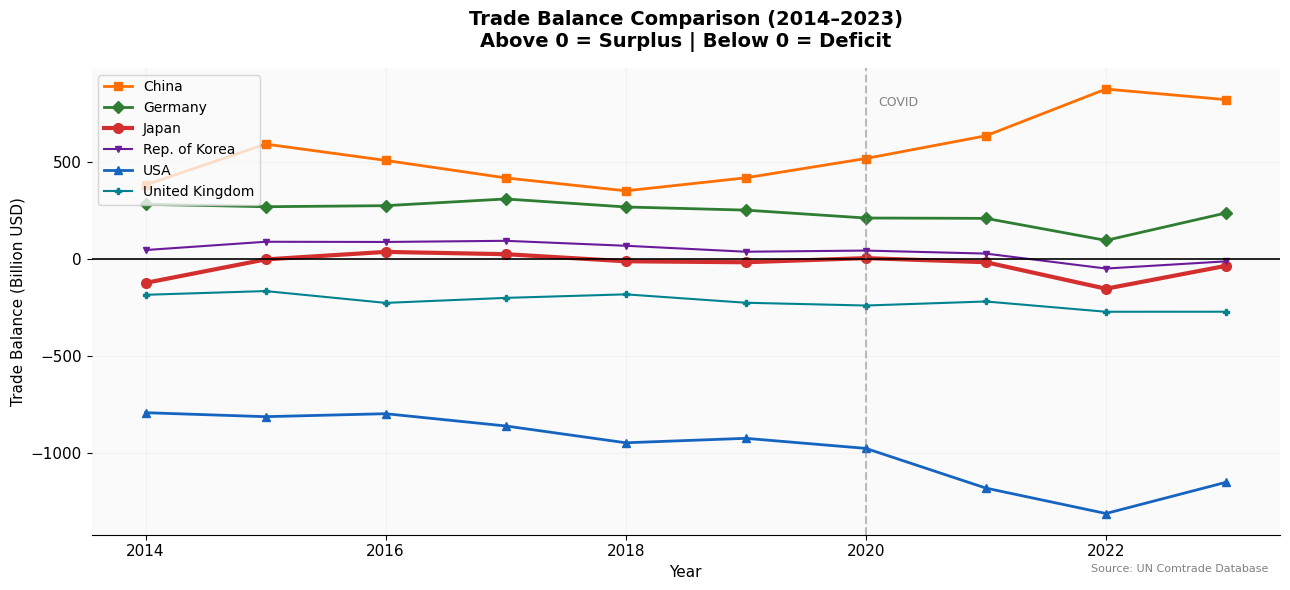

✓ Chart saved


In [11]:
# WHY grouped line chart for balance:
# Shows how each country's surplus/deficit evolved
# We can see which countries strengthened and which weakened

fig, ax = plt.subplots(figsize=(13, 6))

for country in balance_df['country'].unique():
    country_data = balance_df[balance_df['country'] == country]
    if country in country_styles:
        style = country_styles[country]
        ax.plot(country_data['year'],
                country_data['balance_bn'],
                label=country,
                color=style['color'],
                linewidth=style['lw'],
                marker=style['marker'],
                markersize=style['ms'])

ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-')
ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
ax.text(2020.1, balance_df['balance_bn'].max()*0.9,
        'COVID', fontsize=9, color='gray')

ax.set_title("Trade Balance Comparison (2014–2023)\nAbove 0 = Surplus | Below 0 = Deficit",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Trade Balance (Billion USD)", fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)
ax.text(0.99, -0.08, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/comparative_balance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

### 2023 Balance Bar Chart

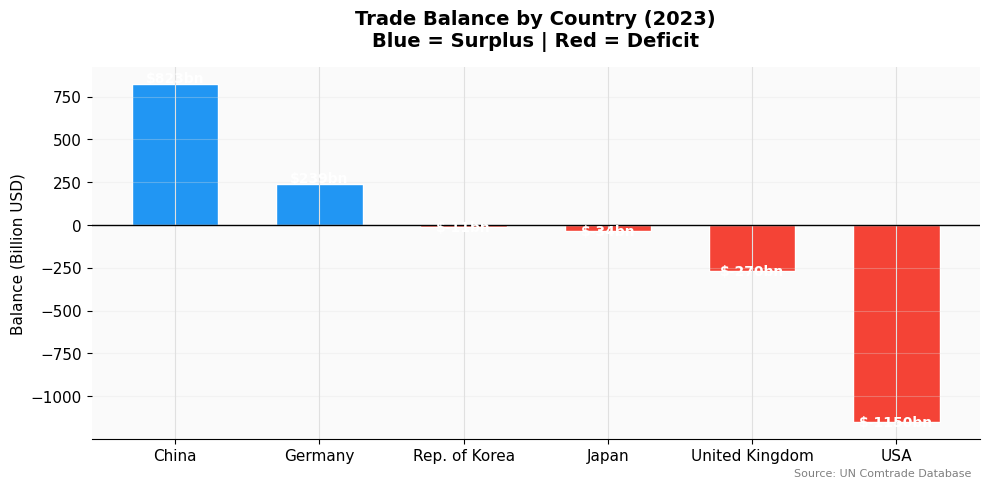

✓ Chart saved


In [12]:
# WHY separate bar chart for 2023:
# The line chart shows trends. This shows the current snapshot.
# Side by side: which economy is healthiest RIGHT NOW?

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#2196F3' if x >= 0 else '#F44336'
          for x in balance_2023['balance_bn']]

bars = ax.bar(balance_2023['country'],
              balance_2023['balance_bn'],
              color=colors, edgecolor='white', width=0.6)

for bar, val in zip(bars, balance_2023['balance_bn']):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (10 if val >= 0 else -25),
            f'${val:.0f}bn',
            ha='center', fontsize=10, fontweight='bold',
            color='white')

ax.axhline(y=0, color='black', linewidth=1)
ax.set_title("Trade Balance by Country (2023)\nBlue = Surplus | Red = Deficit",
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Balance (Billion USD)", fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.text(0.99, -0.1, 'Source: UN Comtrade Database',
        transform=ax.transAxes, fontsize=8,
        color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/balance_2023_ranking.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

## Yen Analysis

In [13]:
## FRED = Federal Reserve Economic Data
# Maintained by the US Federal Reserve Bank of St. Louis
# Contain USD/JYP exchange rate going back decades
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()

fred = Fred(api_key=os.environ.get('FRED_API_KEY'))
print("FRED connected" if fred else "Missing FRED_API_KEY")

FRED connected


### Fetch USD/JPY data:

In [14]:
# DEXJPUS = Daily Exchange rate Japan US
# Higher Number = weaker yen (more yen needed per dollar)
# Lower Number = stronger yen (fewer yen needed per dollar)

yen_daily = fred.get_series('DEXJPUS', 
                            observation_start='2014-01-10',
                            observation_end='2023-12-31')


# Why resample to annual average:
# Daily data = 2,500+ data points - too noisy for trade comparison 
# Our trade data is annual -> match the frequency 
# Annual average = smooths daily volatility, gives clean trend

yen_annual = (yen_daily
              .resample('YE')
              .mean()
              .reset_index())

yen_annual.columns = ['date', 'usd_jpy']
yen_annual['year'] = yen_annual['date'].dt.year
yen_annual = yen_annual[['year', 'usd_jpy']].copy()

print("USD/JPY Annual Average:")
print(yen_annual.to_string(index=False))

USD/JPY Annual Average:
 year    usd_jpy
 2014 105.766885
 2015 121.049084
 2016 108.656932
 2017 112.098554
 2018 110.397390
 2019 109.018835
 2020 106.775440
 2021 109.842892
 2022 131.458920
 2023 140.500120


### Plot: Yen Trend

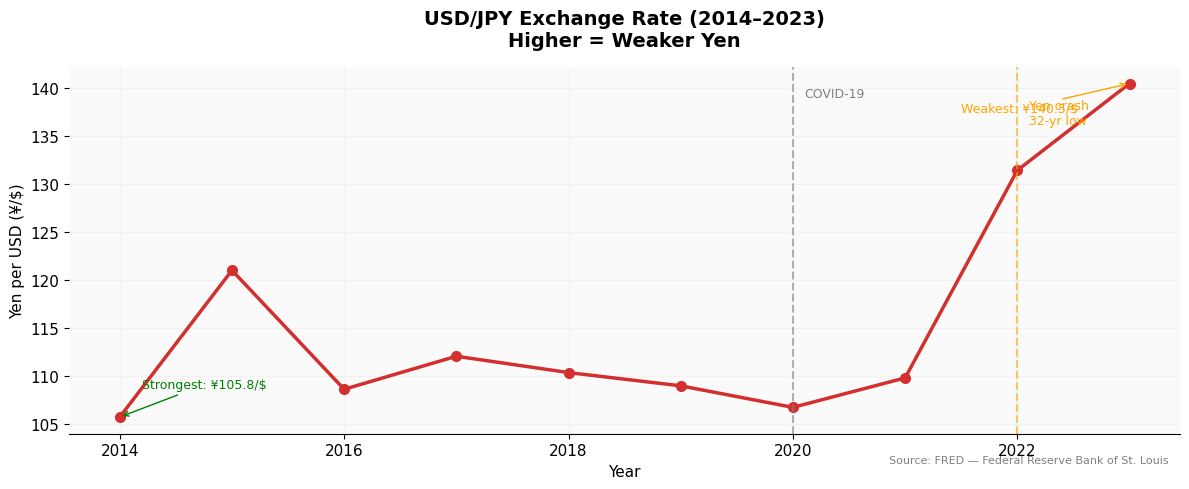

✓ Chart saved


In [15]:
# WHY invert the y-axis:
# Convention: higher USD/JPY = weaker yen
# But visually "going up" feels like "getting stronger"
# Inverting axis means "going up" = yen strengthening
# This matches how news media shows yen charts
# Makes the chart intuitive to read

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yen_annual['year'], yen_annual['usd_jpy'],
        marker='o', linewidth=2.5, color='#D32F2F',
        markersize=7, label='USD/JPY rate')

# Annotate key events
ax.axvline(x=2020, color='gray', linestyle='--', alpha=0.6)
ax.text(2020.1, yen_annual['usd_jpy'].max()*0.99,
        'COVID-19', fontsize=9, color='gray')

ax.axvline(x=2022, color='orange', linestyle='--', alpha=0.6)
ax.text(2022.1, yen_annual['usd_jpy'].max()*0.97,
        'Yen crash\n32-yr low', fontsize=9, color='orange')

# Mark highest and lowest points
max_idx = yen_annual['usd_jpy'].idxmax()
min_idx = yen_annual['usd_jpy'].idxmin()

ax.annotate(f"Weakest: ¥{yen_annual.loc[max_idx,'usd_jpy']:.1f}/$",
            xy=(yen_annual.loc[max_idx,'year'],
                yen_annual.loc[max_idx,'usd_jpy']),
            xytext=(yen_annual.loc[max_idx,'year']-1.5,
                    yen_annual.loc[max_idx,'usd_jpy']-3),
            fontsize=9, color='orange',
            arrowprops=dict(arrowstyle='->', color='orange'))

ax.annotate(f"Strongest: ¥{yen_annual.loc[min_idx,'usd_jpy']:.1f}/$",
            xy=(yen_annual.loc[min_idx,'year'],
                yen_annual.loc[min_idx,'usd_jpy']),
            xytext=(yen_annual.loc[min_idx,'year']+0.2,
                    yen_annual.loc[min_idx,'usd_jpy']+3),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_title("USD/JPY Exchange Rate (2014–2023)\nHigher = Weaker Yen",
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Yen per USD (¥/$)", fontsize=11)
ax.grid(True, alpha=0.3)
ax.text(0.99, -0.08, 'Source: FRED — Federal Reserve Bank of St. Louis',
        transform=ax.transAxes, fontsize=8, color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/yen_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")


### Yen vs Trade Balance Overlay

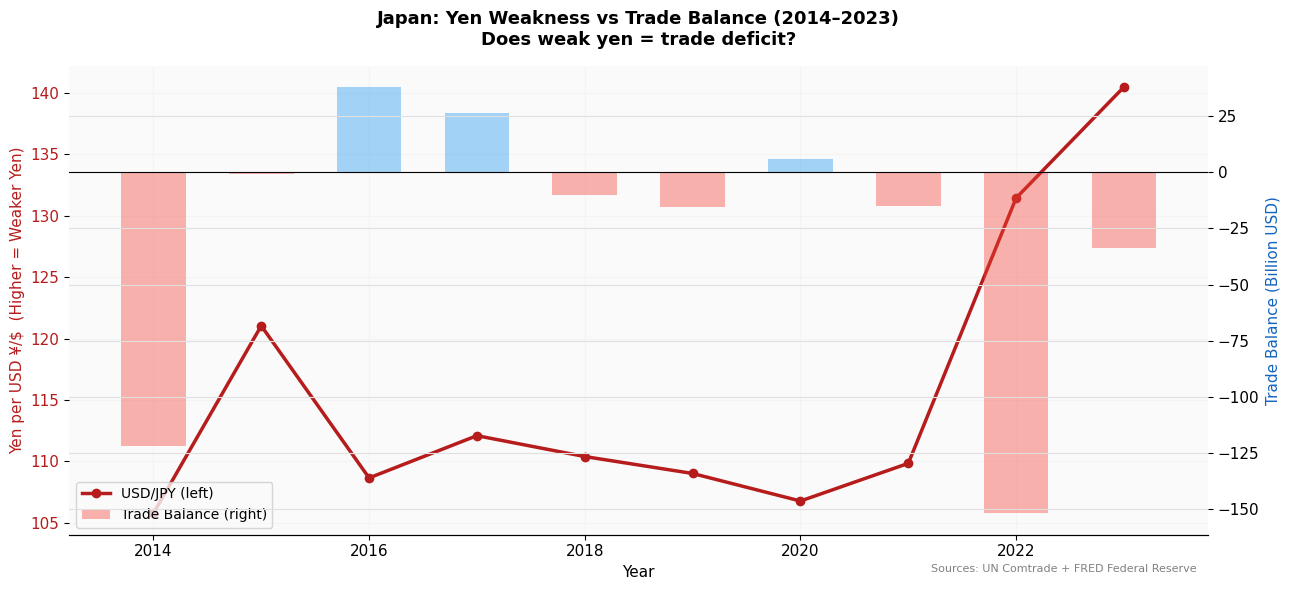

✓ Chart saved


In [16]:
# WHY dual-axis chart:
# Yen rate and trade balance are in completely different units
# Yen: 105-145 range. Trade balance: -152 to +38 billion USD
# Putting both on one axis makes one line invisible
# Dual axis = each metric uses its own scale
# but both share the same x-axis (year) for comparison

# Get Japan trade balance
japan_world = master[
    (master['reporter'] == 'Japan') &
    (master['partner'] == 'World')
].copy()

exp = japan_world[japan_world['flow']=='Export'][['year','value_usd']].rename(
    columns={'value_usd':'exp_usd'})
imp = japan_world[japan_world['flow']=='Import'][['year','value_usd']].rename(
    columns={'value_usd':'imp_usd'})

japan_balance = exp.merge(imp, on='year')
japan_balance['balance_bn'] = (japan_balance['exp_usd'] -
                                japan_balance['imp_usd']) / 1e9

# Merge with yen data
combined = japan_balance.merge(yen_annual, on='year')

fig, ax1 = plt.subplots(figsize=(13, 6))

# WHY color red for yen (ax1) and blue/red for balance (ax2):
# Red = yen (Japan's national color association)
# Blue surplus, Red deficit = intuitive for balance

color_yen = '#B71C1C'
ax1.plot(combined['year'], combined['usd_jpy'],
         color=color_yen, linewidth=2.5,
         marker='o', markersize=6, label='USD/JPY (left)')
ax1.set_ylabel("Yen per USD ¥/$  (Higher = Weaker Yen)",
               color=color_yen, fontsize=11)
ax1.tick_params(axis='y', labelcolor=color_yen)

ax2 = ax1.twinx()

# WHY twinx():
# Creates a second y-axis that shares the same x-axis
# Perfect for comparing two metrics with different scales

bar_colors = ['#2196F3' if x >= 0 else '#F44336'
              for x in combined['balance_bn']]
ax2.bar(combined['year'], combined['balance_bn'],
        color=bar_colors, alpha=0.4, width=0.6,
        label='Trade Balance (right)')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_ylabel("Trade Balance (Billion USD)",
               color='#1565C0', fontsize=11)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=10, loc='lower left')

ax1.set_title("Japan: Yen Weakness vs Trade Balance (2014–2023)\n"
              "Does weak yen = trade deficit?",
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Year", fontsize=11)
ax1.grid(True, alpha=0.2)
ax1.text(0.99, -0.08,
         'Sources: UN Comtrade + FRED Federal Reserve',
         transform=ax1.transAxes, fontsize=8,
         color='gray', ha='right')

plt.tight_layout()
plt.savefig("../reports/yen_vs_balance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved")

### Correlation: Yen vs Trade Balance

In [17]:
# WHY correlation here:
# The chart shows the visual relationship
# The correlation coefficient gives us the STRENGTH
# of that relationship as a single number

# WHY Pearson correlation specifically:
# Pearson measures LINEAR relationship between two variables
# Range: -1 to +1
# +1 = perfect positive (both move together)
# -1 = perfect negative (one goes up, other goes down)
#  0 = no linear relationship

corr = combined['usd_jpy'].corr(combined['balance_bn'])

print("=== YEN vs TRADE BALANCE CORRELATION ===")
print(f"Pearson correlation: {corr:.4f}")
print()

if corr < -0.5:
    print("Strong NEGATIVE correlation:")
    print("→ When yen weakens (USD/JPY rises), trade balance worsens")
    print("→ Weak yen hurts Japan's trade position")
elif corr > 0.5:
    print("Strong POSITIVE correlation:")
    print("→ When yen weakens, trade balance improves")
    print("→ Weak yen helps Japan's exports")
else:
    print("Weak correlation:")
    print("→ Yen and trade balance don't move together consistently")
    print("→ Other factors dominate Japan's trade position")

print()
print("Year by year:")
print(combined[['year','usd_jpy','balance_bn']].to_string(index=False))

=== YEN vs TRADE BALANCE CORRELATION ===
Pearson correlation: -0.3437

Weak correlation:
→ Yen and trade balance don't move together consistently
→ Other factors dominate Japan's trade position

Year by year:
 year    usd_jpy  balance_bn
 2014 105.766885 -121.967285
 2015 121.049084   -0.694913
 2016 108.656932   38.008393
 2017 112.098554   26.210557
 2018 110.397390  -10.330223
 2019 109.018835  -15.406323
 2020 106.775440    5.880247
 2021 109.842892  -15.209936
 2022 131.458920 -151.927797
 2023 140.500120  -33.803960


## Key Finding 7 — Yen Weakness ≠ Trade Balance Improvement


Paragraph 1: What the USD/JPY rate did 2014-2023 
(In 2014 yen is strongest in our dataset
In 2015: Yen crash 105 to 121 (BOJ stimulus)
In 2016: Yen recoverd then 2017-2019 the yen was stable and im 2020 because of COVID yen strengthend in 2021 yen return it to normal but in 2022 -> yen crashed so brutally (because of Fed raised rates, BOJ didn't)
The US Federal Reserve raised interest rates aggerssively to fight inflation. Japan's Bank of Japan kept rates
near zero. When US rates go up and Japan rates stay flat, investors move money to USD becuase of higher returns, Massive 
capital outflow from Japan = yen collapses. From 115yen to 150yen in just one year.)

Paragraph 2: The correlation coefficient (-0.34) and what it means
(The naive expectation was: Weak yen -> Japanese Exports become cheaper for foreigners -> exports increas -> trade balance imporvers.  )

Paragraph 3: WHY the relationship is weak — the energy paradox
(Japan's energy paradox: Japan imports ~90% of its energy. Energy is price globally in USD. When the yen weakens:
export side: Japanese cars/electronics become cheaper for foreign buyers
but import side:Every barrel of oil, every LNG shipment Cost MORE in yen.
In 2022, Energy prices also EXPLODED (Russia-Ukraine War). So Japan had BOTH yen weakness And High energy price simultaneously. The energy import bull overwhelmed any export gains )

Paragraph 4: The 2022 proof — both yen AND energy prices hit Japan
simultaneously. That's why -$152bn was so extreme.
(In 2022, Energy prices also EXPLODED (Russia-Ukraine War). So Japan had BOTH yen weakness And High energy price simultaneously. The energy import bull overwhelmed any export gains )

Paragraph 5: What this means for METI policy
(controlling the trade balance requires energy transition,
not just currency management)